分析负样本特征: 100%|██████████| 21572/21572 [00:05<00:00, 4217.50it/s]


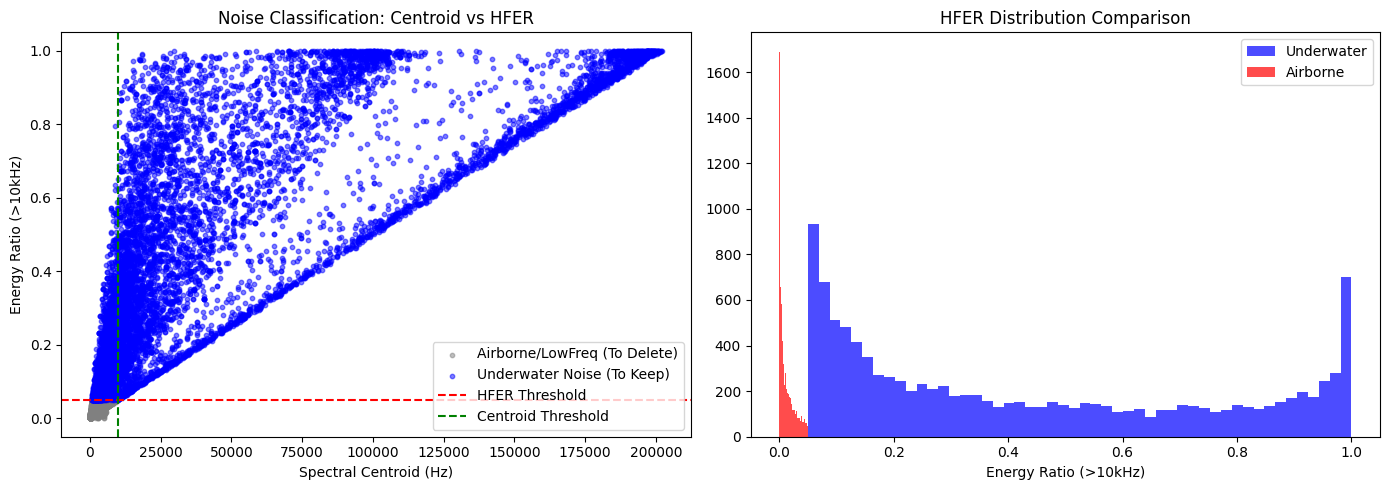

分析报告:
 - 原始负样本总数: 21572
 - 识别并剔除空气/无效低频噪声: 10576 (49.03%)
 - 保留水下困难负样本: 10996 (50.97%)


In [2]:
import os
import glob
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_noise_type(file_path, cutoff_hz=10000):
    """
    分析噪声特征
    cutoff_hz: 设定为10kHz，这是区分空气/水下噪声的黄金分割点
    """
    try:
        # 加载音频 (sr=None 保持原始高采样率)
        y, sr = librosa.load(file_path, sr=None)
        if len(y) == 0: return None
        
        # 1. 计算功率谱密度 (PSD)
        fft = np.abs(np.fft.rfft(y))
        psd = fft**2
        freqs = np.fft.rfftfreq(len(y), 1/sr)
        
        # 2. 计算高频能量占比 (HFER) - 针对 10kHz 以上
        total_energy = np.sum(psd)
        if total_energy == 0: return None
        
        high_freq_mask = freqs >= cutoff_hz
        high_freq_energy = np.sum(psd[high_freq_mask])
        hfer = high_freq_energy / total_energy
        
        # 3. 计算频谱质心
        centroid = np.sum(freqs * psd) / total_energy
        
        return {
            'path': file_path,
            'hfer_10k': hfer,      # 10kHz以上能量占比
            'centroid': centroid,
            'filename': os.path.basename(file_path)
        }
    except Exception as e:
        return None

# --- 1. 路径设置 ---
NEG_DIR = r"D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\02_ClickDetection\FalseClick"
all_neg_files = glob.glob(os.path.join(NEG_DIR, "**", "*.wav"), recursive=True)

# --- 2. 特征提取 ---
results = []
for f in tqdm(all_neg_files, desc="分析负样本特征"):
    res = analyze_noise_type(f)
    if res:
        results.append(res)

df = pd.DataFrame(results)

# --- 3. 设定剔除阈值 ---
# 根据物理特性：
# 空气噪声：10kHz以上几乎无能量 (hfer_10k < 0.01) 且 质心很低 (centroid < 8000)
# 水下噪声：即使是水流或碰撞，其10kHz以上也会有碎屑能量，或者质心较高
hfer_threshold = 0.05      # 1% 的能量占比
centroid_threshold = 10000  # 8kHz 的质心

# 判定为【水下噪声】的条件（满足其一即可保留）：
# 1. 10kHz以上能量占比超过 1% 
# 2. 或者 频谱质心超过 8kHz
underwater_mask = (df['hfer_10k'] >= hfer_threshold) | (df['centroid'] >= centroid_threshold)

underwater_negatives = df[underwater_mask].copy()
airborne_negatives = df[~underwater_mask].copy()

# --- 4. 可视化对比 ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(airborne_negatives['centroid'], airborne_negatives['hfer_10k'], 
            alpha=0.5, s=10, label='Airborne/LowFreq (To Delete)', color='gray')
plt.scatter(underwater_negatives['centroid'], underwater_negatives['hfer_10k'], 
            alpha=0.5, s=10, label='Underwater Noise (To Keep)', color='blue')
plt.axhline(y=hfer_threshold, color='r', linestyle='--', label='HFER Threshold')
plt.axvline(x=centroid_threshold, color='g', linestyle='--', label='Centroid Threshold')
plt.title('Noise Classification: Centroid vs HFER')
plt.xlabel('Spectral Centroid (Hz)')
plt.ylabel('Energy Ratio (>10kHz)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(underwater_negatives['hfer_10k'], bins=50, color='blue', alpha=0.7, label='Underwater')
plt.hist(airborne_negatives['hfer_10k'], bins=50, color='red', alpha=0.7, label='Airborne')
plt.title('HFER Distribution Comparison')
plt.xlabel('Energy Ratio (>10kHz)')
plt.legend()

plt.tight_layout()
plt.show()

# --- 5. 结果输出 ---
print(f"========================================")
print(f"分析报告:")
print(f" - 原始负样本总数: {len(df)}")
print(f" - 识别并剔除空气/无效低频噪声: {len(airborne_negatives)} ({(len(airborne_negatives)/len(df)*100):.2f}%)")
print(f" - 保留水下困难负样本: {len(underwater_negatives)} ({(len(underwater_negatives)/len(df)*100):.2f}%)")
print(f"========================================")

# 导出清洗后的水下负样本路径
underwater_negatives['path'].to_csv("filtered_underwater_negatives.csv", index=False)